# Покупательское намерение в интернет-магазине
Цель этого ноутбука показать: загрузку данных, EDA, предобработку, обучение нескольких моделей, сравнение метрик, выбор лучшей модели и сохранение артефактов.

**Целевая переменная:** `Revenue`.

**Тип задачи:** бинарная классификация.

# 1. Установка зависимостей

В Colab большинство библиотек уже установлены, но `catboost` обычно нужно поставить отдельно.

In [4]:
!pip -q install catboost scikit-learn seaborn joblib

# 2. Импорты и настройки

- А также задаём основные константы проекта: фиксируем `RANDOM_STATE`, чтобы результаты можно было воспроизвести
- Указываем размер тестовой выборки `TEST_SIZE = 0.2`, то есть 20% данных уйдёт на проверку модели,
- Задаём целевой столбец `Revenue`, который модель будет предсказывать.


In [5]:
import json
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.2
TARGET_COLUMN = "Revenue"

sns.set_theme(style="whitegrid")


# 3. Загрузка `data.csv`

In [6]:
df = pd.read_csv('/content/data.csv')
print(df.shape)
df

(12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


# 4. Проверка структуры датасета

Здесь я решил сразу проверить, что в датасете есть все нужные колонки и ничего не потерялось при загрузке данных. Если какой-то столбец отсутствует, программа сразу выдаст ошибку с названием пропущенных колонок.


In [7]:
EXPECTED_COLUMNS = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend",
    "Revenue",
]

missing_columns = [column for column in EXPECTED_COLUMNS if column not in df.columns]
if missing_columns:
    raise ValueError(f"Нет обязательных колонок: {missing_columns}")

print("Все ожидаемые колонки присутствуют.")
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} колонок")

Все ожидаемые колонки присутствуют.
Размер датасета: 12330 строк, 18 колонок


# 5. EDA: базовая информация

Тут смотрю на общую информацию по датасету обыденный `describe`, `info`

- Для числовых признаков можно посмотреть среднее значение, минимумы, максимумы и квартили,
- Для категориальных — количество уникальных значений и самые частые категории.

После этого отдельно формирую таблицу с пропусками. В ней показывается не только количество пустых значений, но и их доля относительно всего датасета. Это поможет дальше понять, нужна ли обработка пропусков перед обучением моделей.

In [8]:
df.info()
display(df.describe(include="all"))

missing_report = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_share": (df.isna().sum() / len(df)).round(4),
})
missing_report

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330,12330.000000,12330.000000,12330.000000,12330.000000,12330,12330,12330
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,NaN,3,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,May,NaN,NaN,NaN,NaN,Returning_Visitor,False,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3364,NaN,NaN,NaN,NaN,10551,9462,10422
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,NaN,2.124006,2.357097,3.147364,4.069586,NaN,NaN,NaN
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,NaN,0.911325,1.717277,2.401591,4.025169,NaN,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,NaN,2.000000,2.000000,1.000000,2.000000,NaN,NaN,NaN
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,NaN,2.000000,2.000000,3.000000,2.000000,NaN,NaN,NaN
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,NaN,3.000000,2.000000,4.000000,4.000000,NaN,NaN,NaN


,missing_count,missing_share
Administrative,0,0.0
Administrative_Duration,0,0.0
Informational,0,0.0
Informational_Duration,0,0.0
ProductRelated,0,0.0
ProductRelated_Duration,0,0.0
BounceRates,0,0.0
ExitRates,0,0.0
PageValues,0,0.0
SpecialDay,0,0.0


# 6. EDA: целевая переменная и дисбаланс классов

Здесь смотрю на распределение целевой переменной `Revenue`, то есть сколько в датасете сессий с покупкой и без покупки.

Сначала считаю количество объектов каждого класса через, а потом вычисляю долю покупок. Это важно проверить до обучения моделей, потому что сильный дисбаланс классов может влиять на качество предсказаний.

В моём случае видно, что покупок заметно меньше, чем обычных посещений без покупки. Из-за этого одной метрики accuracy будет недостаточно: модель может показывать высокий accuracy просто предсказывая почти всегда отсутствие покупки.

Поэтому дальше при оценке моделей нужно обращать внимание ещё и на `precision`, `recall`, `F1-score` и `ROC-AUC`, так как они лучше показывают качество работы на несбалансированных данных.

,count
Revenue,
False,10422
True,1908


Доля покупок: 15.47%


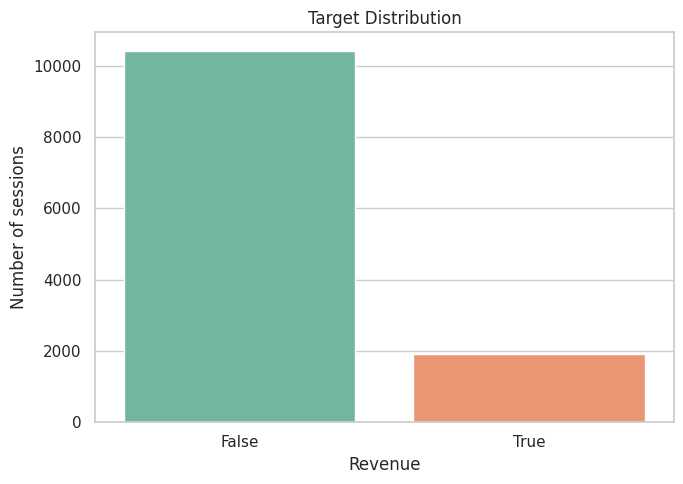

In [9]:
target_counts = df[TARGET_COLUMN].value_counts(dropna=False)
purchase_share = df[TARGET_COLUMN].mean()

display(target_counts.rename("count").to_frame())
print(f"Доля покупок: {purchase_share:.2%}")

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x=TARGET_COLUMN, hue=TARGET_COLUMN, palette="Set2", legend=False)
plt.title("Target Distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of sessions")
plt.tight_layout()
plt.show()

### Вывод по целевой переменной

В датасете заметен дисбаланс классов: сессий без покупки значительно больше, чем сессий с покупкой. Для задачи интернет-магазина это ожидаемо, потому что большинство пользователей просматривают сайт, но не всегда завершают визит заказом.

Из-за такого дисбаланса нельзя оценивать модель только по accuracy. Модель может часто предсказывать класс «нет покупки» и всё равно получать высокую точность. Поэтому дальше для сравнения моделей используются precision, recall, F1-score и ROC-AUC.


# 7. EDA: числовые и категориальные признаки

Тут я разделяю признаки на группы, чтобы дальше было удобнее делать предобработку данных и анализ.

Числовые признаки складываю в `NUMERIC_FEATURES`. Это различные длительности, количество просмотров страниц, показатели отказов и другие численные характеристики поведения пользователя на сайте.

Категориальные признаки разделяю отдельно:
- текстовые (`Month`, `VisitorType`)
- числовые категории (`Browser`, `Region` и т.д.)
- булевы значения (`Weekend`).

Дальше для всех категориальных признаков смотрю распределение значений через `value_counts()`. Это помогает понять, какие категории встречаются чаще всего, есть ли редкие значения и насколько данные сбалансированы внутри признаков.

In [10]:
NUMERIC_FEATURES = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
]

STRING_CATEGORICAL_FEATURES = ["Month", "VisitorType"]
NUMERIC_CATEGORICAL_FEATURES = ["OperatingSystems", "Browser", "Region", "TrafficType"]
BOOLEAN_CATEGORICAL_FEATURES = ["Weekend"]
CATEGORICAL_FEATURES = STRING_CATEGORICAL_FEATURES + NUMERIC_CATEGORICAL_FEATURES + BOOLEAN_CATEGORICAL_FEATURES

display(df[NUMERIC_FEATURES].describe().T)

for column in CATEGORICAL_FEATURES:
    print(f"\n{column}")
    display(df[column].value_counts(dropna=False).to_frame("count"))

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000



Month


,count
Month,
May,3364
Nov,2998
Mar,1907
Dec,1727
Oct,549
Sep,448
Aug,433
Jul,432
June,288



VisitorType


,count
VisitorType,
Returning_Visitor,10551
New_Visitor,1694
Other,85


...

,count
Region,
1,4780
3,2403
4,1182
2,1136
6,805
7,761
9,511
8,434
5,318



TrafficType


,count
TrafficType,
2,3913
1,2451
3,2052
4,1069
13,738
10,450
6,444
8,343
5,260



Weekend


,count
Weekend,
False,9462
True,2868


## Вывод по данным
Во-первых, большинство пользователей не тратит много времени на административные и информационные страницы: медиана (50%) равна нулю, то есть половина сессий вообще их не касается. В то же время вкладка с продуктами явно ключевая: люди в среднем просматривают около 18–38 страниц с товарами, а в некоторых случаях — сотни.

Показатели отказов и выходов невысокие (медианные значения около 2-5%), но есть сессии с высокими показателями, что может означать, что часть пользователей быстро покидает сайт. При этом большинство сессий не приносит ценности (`PageValues` для 75% равен нулю).

По месяцам видно, что больше всего сессий в мае и ноябре — возможно, это пики активности перед праздниками или акциями. Возвращающиеся посетители — основная аудитория (85%), что значит, что повторные визиты важны для покупок.

Наконец, большинство сессий происходит не в выходные (около 77%), но покупки в выходные тоже стоит учитывать, так как их доля заметна.


# 8. EDA: графики
Здесь уже начинаю смотреть связи между признаками и искать закономерности, которые могут быть полезны модели.

Сначала строю корреляционную матрицу для числовых признаков и целевой переменной.

Дальше анализирую покупки по месяцам. Считаю среднюю долю покупок для каждого месяца и строю график. Так можно заметить сезонность и понять, в какие месяцы пользователи чаще совершают покупки.

После этого смотрю зависимость покупок от типа посетителя (`VisitorType`). Интересно проверить, кто чаще покупает: новые пользователи, возвращающиеся или другие категории посетителей.

В конце отдельно анализирую влияние выходных дней (`Weekend`). Проверяю, меняется ли вероятность покупки в зависимости от того, была ли сессия в выходной день или нет.


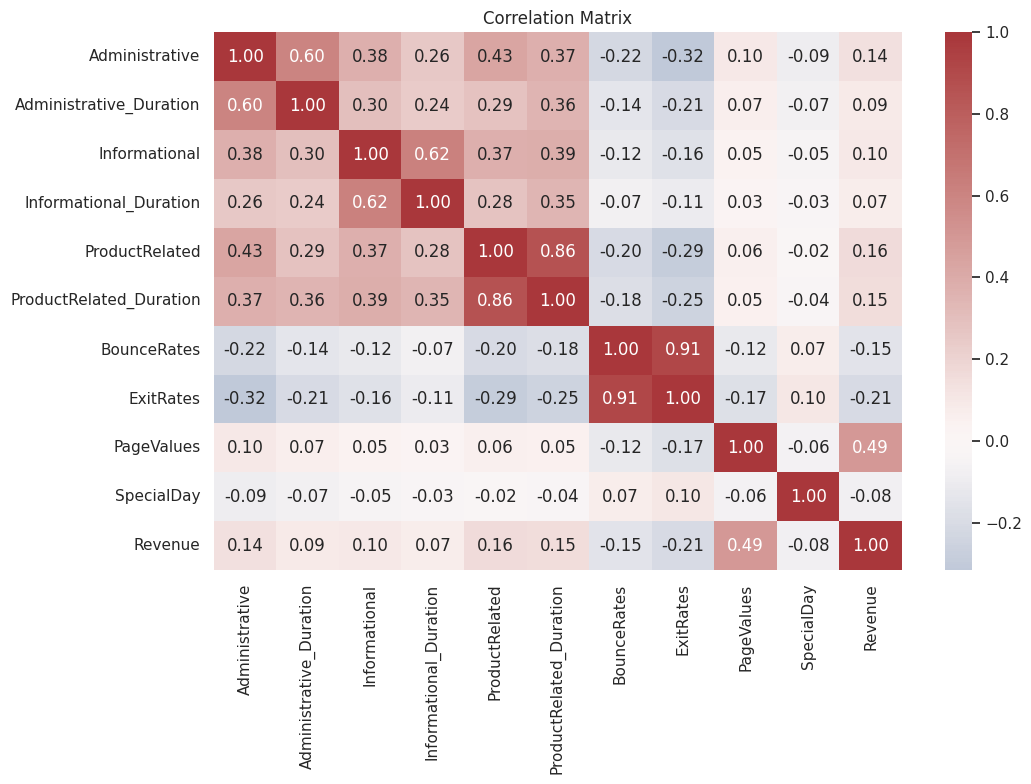

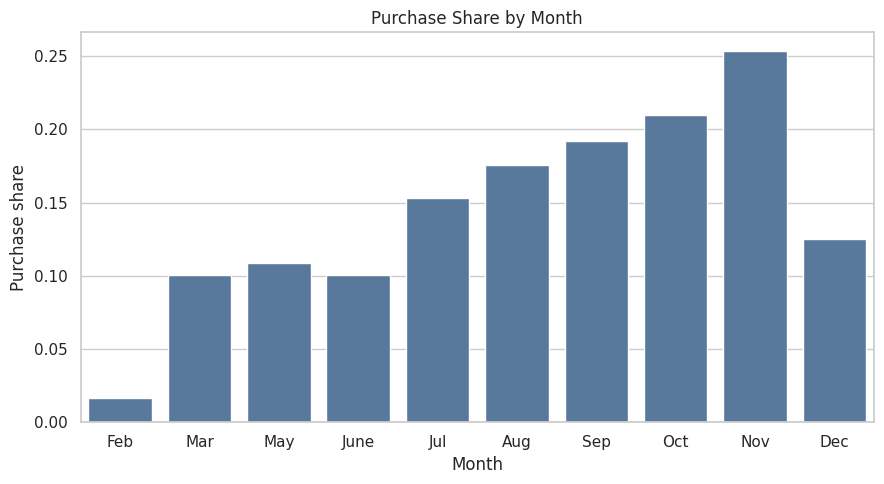

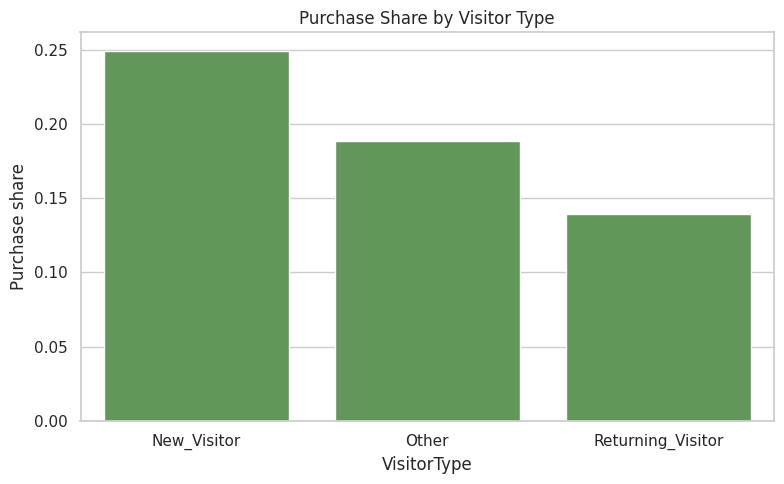

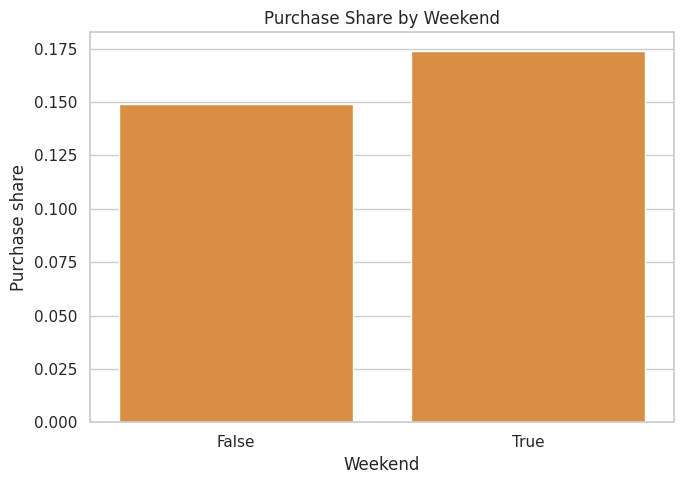

In [11]:
corr_df = df[NUMERIC_FEATURES + [TARGET_COLUMN]].copy()
corr_df[TARGET_COLUMN] = corr_df[TARGET_COLUMN].astype(int)

plt.figure(figsize=(11, 8))
sns.heatmap(corr_df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

month_order = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_revenue = df.groupby("Month", observed=False)[TARGET_COLUMN].mean().reindex(month_order).dropna().reset_index()
plt.figure(figsize=(9, 5))
sns.barplot(data=monthly_revenue, x="Month", y=TARGET_COLUMN, color="#4c78a8")
plt.title("Purchase Share by Month")
plt.ylabel("Purchase share")
plt.tight_layout()
plt.show()

visitor_revenue = df.groupby("VisitorType", observed=False)[TARGET_COLUMN].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=visitor_revenue, x="VisitorType", y=TARGET_COLUMN, color="#59a14f")
plt.title("Purchase Share by Visitor Type")
plt.ylabel("Purchase share")
plt.tight_layout()
plt.show()

weekend_revenue = df.groupby("Weekend", observed=False)[TARGET_COLUMN].mean().reset_index()
plt.figure(figsize=(7, 5))
sns.barplot(data=weekend_revenue, x="Weekend", y=TARGET_COLUMN, color="#f28e2b")
plt.title("Purchase Share by Weekend")
plt.ylabel("Purchase share")
plt.tight_layout()
plt.show()

### Вывод по графикам EDA

Графики помогают увидеть, что покупательское поведение зависит не только от одного признака. Месяц, тип посетителя и выходной день могут быть связаны с вероятностью покупки, но сами по себе не дают полного ответа.

Это подтверждает, что задачу лучше решать не простыми правилами, а моделью машинного обучения, которая сможет учитывать несколько признаков одновременно.


## Анализ распределений и выбросов

В этом блоке решил подробнее посмотреть на распределение некоторых важных признаков и проверить наличие выбросов.

Сначала строю гистограммы для `PageValues`, `ExitRates` и `BounceRates` с разделением по целевой переменной `Revenue`. Это помогает визуально сравнить поведение пользователей, которые совершили покупку, и тех, кто просто покинул сайт.

Например, по таким графикам можно заметить, что у покупателей часто выше `PageValues`, а показатели отказов могут отличаться у разных классов.

Дальше через boxplot смотрю распределение всех числовых признаков сразу. Такой график хорошо показывает разброс значений, медианы и возможные выбросы.

Выбросы здесь специально не удаляю автоматически, потому что в задаче анализа поведения пользователей экстремальные значения могут быть реальными и полезными для модели. Например, очень длинная сессия или большое количество просмотренных страниц вполне могут означать заинтересованного покупателя, а не ошибку в данных.

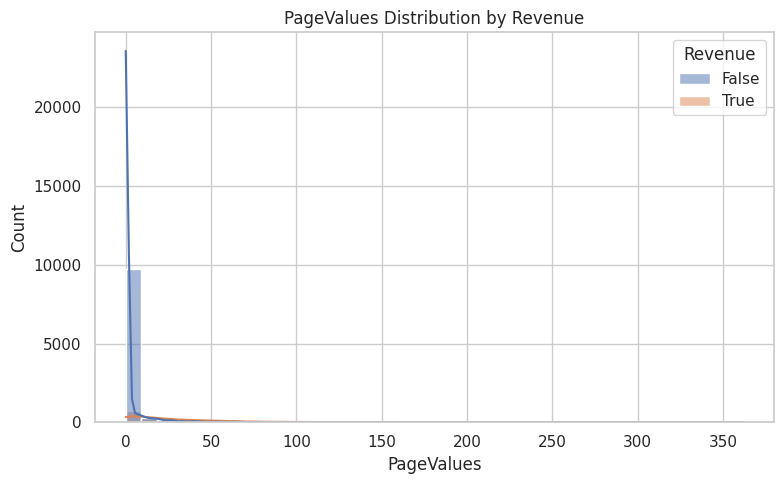

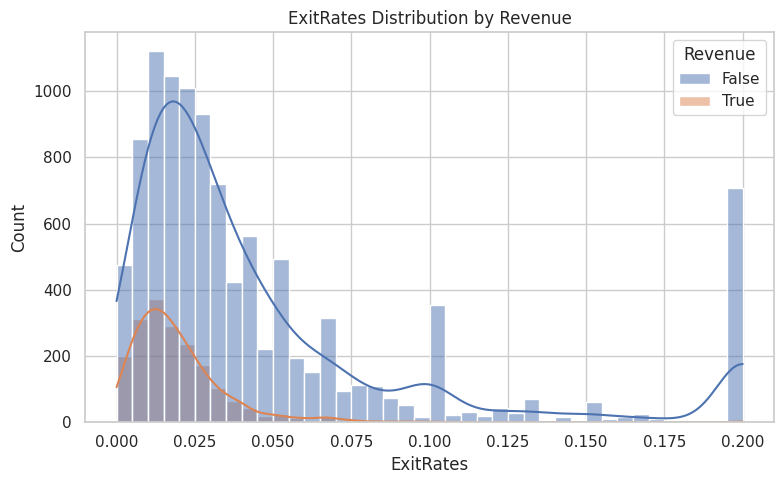

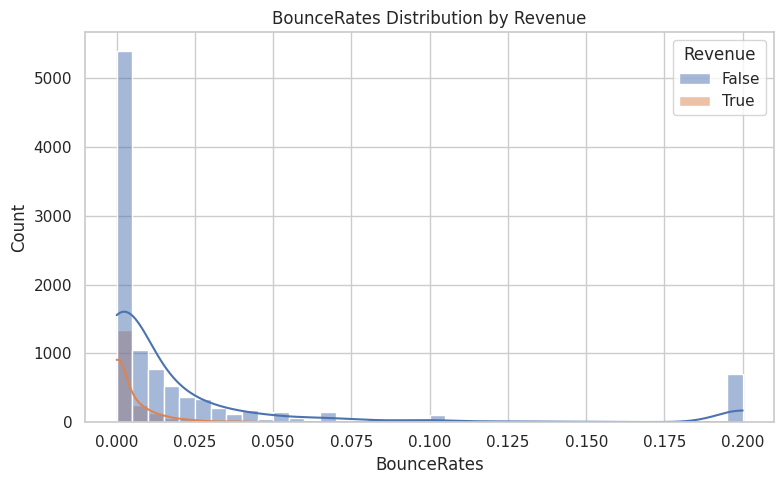

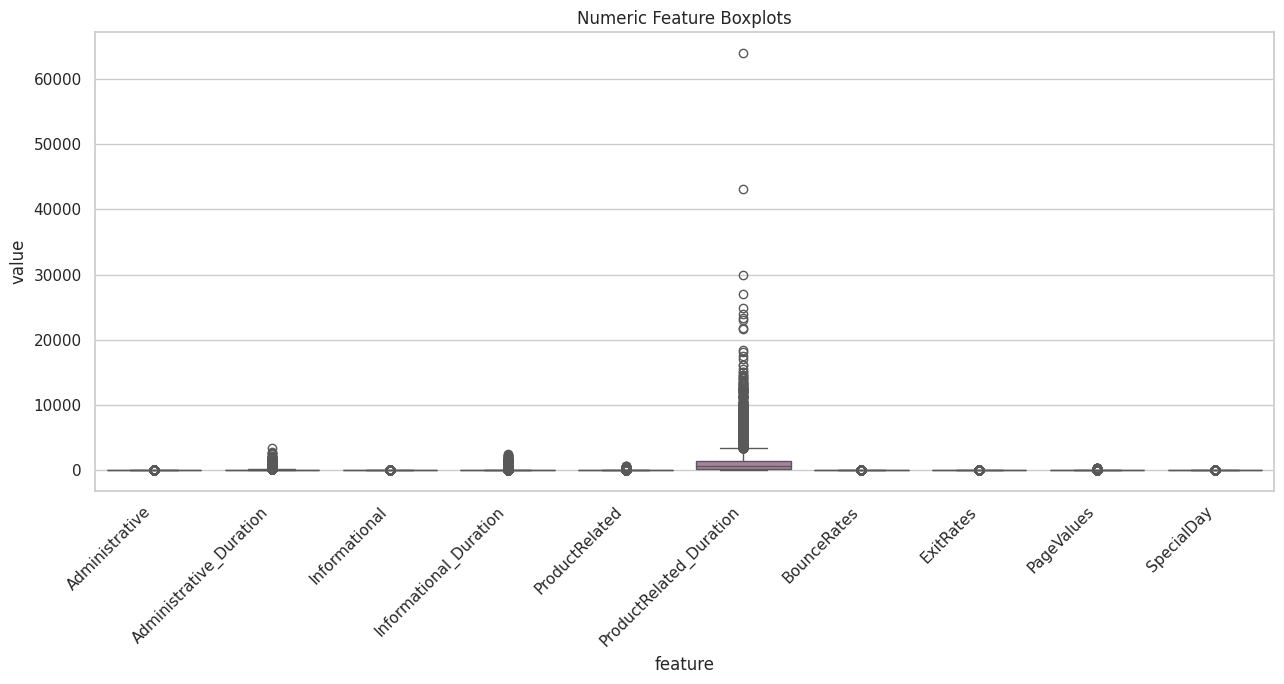

In [12]:
for feature, filename in {
    "PageValues": "pagevalues_distribution.png",
    "ExitRates": "exitrates_distribution.png",
    "BounceRates": "bouncerates_distribution.png",
}.items():
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=feature, hue=TARGET_COLUMN, bins=40, kde=True)
    plt.title(f"{feature} Distribution by Revenue")
    plt.tight_layout()
    plt.show()

melted_numeric = df[NUMERIC_FEATURES].melt(var_name="feature", value_name="value")
plt.figure(figsize=(13, 7))
sns.boxplot(data=melted_numeric, x="feature", y="value", color="#b07aa1")
plt.title("Numeric Feature Boxplots")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Вывод по поведенческим признакам

По распределениям видно, что поведенческие признаки действительно полезны для прогноза. Особенно важным выглядит PageValues: у сессий с покупкой значения этого признака чаще выше, чем у сессий без покупки.

ExitRates и BounceRates тоже несут полезную информацию. Высокие значения могут означать, что пользователь быстро покидает сайт или не находит нужный товар. Такие признаки помогают модели отличать заинтересованные сессии от менее заинтересованных.

Выбросы в этих признаках не удаляются автоматически, потому что в поведении пользователей экстремальные значения могут быть реальными: например, очень длинная сессия или большое количество просмотренных товаров может как раз говорить о высокой заинтересованности.


# 9. Feature engineering

Чтобы усилить проект, добавляю несколько новых признаков, которые логично описывают поведение пользователя в сессии.

Новые признаки:

- `TotalPages` — общее число просмотренных страниц;
- `TotalDuration` — общая длительность сессии по основным группам страниц;
- `ProductPagesShare` — доля товарных страниц среди всех просмотренных страниц;
- `AvgProductDuration` — среднее время на одной товарной странице;
- `HasPageValue` — есть ли у сессии ненулевое значение `PageValues`.

Эти признаки помогают модели учитывать не только отдельные исходные колонки, но и агрегированную вовлечённость пользователя.


In [13]:
df_model = df.copy()

df_model["TotalPages"] = (
    df_model["Administrative"]
    + df_model["Informational"]
    + df_model["ProductRelated"]
)

df_model["TotalDuration"] = (
    df_model["Administrative_Duration"]
    + df_model["Informational_Duration"]
    + df_model["ProductRelated_Duration"]
)

df_model["ProductPagesShare"] = np.where(
    df_model["TotalPages"] > 0,
    df_model["ProductRelated"] / df_model["TotalPages"],
    0.0,
)

df_model["AvgProductDuration"] = np.where(
    df_model["ProductRelated"] > 0,
    df_model["ProductRelated_Duration"] / df_model["ProductRelated"],
    0.0,
)

df_model["HasPageValue"] = (df_model["PageValues"] > 0).astype(int)

ENGINEERED_NUMERIC_FEATURES = [
    "TotalPages",
    "TotalDuration",
    "ProductPagesShare",
    "AvgProductDuration",
    "HasPageValue",
]

NUMERIC_FEATURES = NUMERIC_FEATURES + ENGINEERED_NUMERIC_FEATURES

print("Добавлены новые признаки:")
display(df_model[ENGINEERED_NUMERIC_FEATURES].head())
display(
    df_model[ENGINEERED_NUMERIC_FEATURES + [TARGET_COLUMN]]
    .corr(numeric_only=True)[[TARGET_COLUMN]]
    .sort_values(TARGET_COLUMN, ascending=False)
)


Добавлены новые признаки:


,TotalPages,TotalDuration,ProductPagesShare,AvgProductDuration,HasPageValue
0,1,0.000000,1.0,0.000000,0
1,2,64.000000,1.0,32.000000,0
2,1,0.000000,1.0,0.000000,0
3,2,2.666667,1.0,1.333333,0
4,10,627.500000,1.0,62.750000,0


,Revenue
Revenue,1.000000
HasPageValue,0.602517
TotalPages,0.164110
TotalDuration,0.156068
AvgProductDuration,0.041728
ProductPagesShare,-0.046986


### Вывод по feature engineering

Новые признаки помогают компактно описать общую активность пользователя.
- TotalPages показывает глубину просмотра
- TotalDuration — суммарное время взаимодействия
- ProductPagesShare — насколько сессия сфокусирована именно на товарах
- HasPageValue фиксирует сам факт наличия ценности страницы.

Это полезно, потому что покупательское намерение обычно проявляется не в одном отдельном действии, а в комбинации поведения: пользователь смотрит товары, проводит время на сайте, возвращается к ценным страницам и постепенно приближается к покупке.

Важно, что эти признаки потом используются внутри общего pipeline. Значит, backend сможет принимать сырые входные данные, а все дополнительные признаки будут рассчитываться автоматически.


# 10. Предобработка данных

Здесь создаю отдельную систему предобработки данных, чтобы потом одинаково и удобно обрабатывать признаки для всех моделей.

Сначала делаю функцию для создания `OneHotEncoder`. Она нужна для преобразования категориальных признаков в числовой вид, потому что модели машинного обучения не умеют работать со строками напрямую. Параметр `handle_unknown="ignore"` нужен на случай, если в тестовых данных встретится новая категория, которой не было при обучении.

Дальше создаю пайплайны для разных типов признаков.

Для числовых признаков:
- пропуски заменяются медианой,
- после этого данные масштабируются через `StandardScaler`.

Масштабирование особенно важно для логистической регрессии, потому что признаки могут иметь очень разные диапазоны значений.

Для категориальных признаков:
- пропуски заменяются самым частым значением,
- затем применяется One-Hot Encoding.

В конце всё объединяю через `ColumnTransformer`. Это позволяет автоматически применять нужную обработку к разным группам признаков и не делать всё вручную для каждого столбца.

In [14]:
def build_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor() -> ColumnTransformer:
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    string_categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", build_one_hot_encoder()),
        ]
    )

    numeric_categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", build_one_hot_encoder()),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, NUMERIC_FEATURES),
            ("string_categorical", string_categorical_pipeline, STRING_CATEGORICAL_FEATURES),
            ("numeric_categorical", numeric_categorical_pipeline, NUMERIC_CATEGORICAL_FEATURES),
            ("boolean_categorical", build_one_hot_encoder(), BOOLEAN_CATEGORICAL_FEATURES),
        ]
    )

### Вывод по предобработке

Предобработка оформлена через Pipeline и ColumnTransformer. Это делает эксперимент корректным: imputer, scaler и encoder обучаются только на train-части, а затем применяются к test-части.

Такой подход снижает риск утечки данных и делает проект ближе к реальному внедрению. В production нельзя вручную готовить признаки отдельно для обучения и отдельно для предсказания, поэтому весь preprocessing должен быть частью единого pipeline.


# 11. Обучение моделей

Здесь разделяю данные на признаки (`X`) и целевую переменную (`y`).  
В `X` остаются все входные признаки, а `Revenue` выносится отдельно как переменная, которую модель должна будет предсказывать.

После этого делю датасет на обучающую и тестовую выборки через `train_test_split()`.

- `X_train`, `y_train` — данные для обучения моделей.
- `X_test`, `y_test` — данные для проверки качества модели на новых данных.

20% данных выделяю под тестирование (`TEST_SIZE = 0.2`).

Параметр `stratify=y` здесь особенно важен, потому что классы несбалансированы. Благодаря стратификации соотношение покупок и непокупок сохраняется примерно одинаковым и в train, и в test выборке.

In [15]:
X = df_model.drop(columns=[TARGET_COLUMN])
y = df_model[TARGET_COLUMN].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True).rename("train_share"))
print(y_test.value_counts(normalize=True).rename("test_share"))


(9864, 22) (2466, 22)
Revenue
0    0.845296
1    0.154704
Name: train_share, dtype: float64
Revenue
0    0.845093
1    0.154907
Name: test_share, dtype: float64


### Вывод по baseline и моделям

Logistic Regression используется как baseline: это простая и понятная модель, с которой удобно сравнивать более сложные алгоритмы. Если сложные модели не дают прироста относительно baseline, значит усложнение не всегда оправдано.

Random Forest и CatBoost выбраны как более сильные алгоритмы для табличных данных. Они лучше работают с нелинейными зависимостями и взаимодействиями признаков, что важно для анализа пользовательских сессий.


Сначала я создаю функцию `build_models()`, где собираю несколько моделей для бинарной классификации. В качестве базовой модели беру логистическую регрессию, потом добавляю случайный лес и CatBoost. После этого отдельно подбираю гиперпараметры для Random Forest через `RandomizedSearchCV`.

Функция `get_positive_scores()` нужна, чтобы получить не просто предсказанный класс, а оценку уверенности модели для положительного класса, то есть для покупки. Это нужно для расчёта кривой ROC-AUC.

Функция `evaluate_model()` считает основные метрики качества: accuracy, precision, recall, F1-score, ROC-AUC, а также confusion matrix и classification report. Так можно смотреть не только на общую точность, но и на то, насколько хорошо модель находит именно покупки.

Так удобнее выбрать лучшую модель: я смотрю не только на accuracy, а в первую очередь на F1 и ROC-AUC, потому что для этой задачи важно нормально находить пользователей, которые действительно совершат покупку.

In [16]:
def build_models() -> dict[str, Any]:
    models: dict[str, Any] = {
        "Logistic Regression": LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    }

    try:
        from catboost import CatBoostClassifier

        models["CatBoost"] = CatBoostClassifier(
            iterations=500,
            learning_rate=0.05,
            depth=6,
            loss_function="Logloss",
            eval_metric="F1",
            random_seed=RANDOM_STATE,
            verbose=False,
        )
    except ImportError:
        models["HistGradientBoosting"] = HistGradientBoostingClassifier(random_state=RANDOM_STATE)

    return models


def get_positive_scores(model: Any, X_data: pd.DataFrame) -> np.ndarray:
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    if hasattr(model, "decision_function"):
        return np.asarray(model.decision_function(X_data))
    raise AttributeError("Model does not support predict_proba or decision_function")


def evaluate_model(model: Any, X_data: pd.DataFrame, y_true: pd.Series) -> dict[str, Any]:
    y_pred = model.predict(X_data)
    y_score = get_positive_scores(model, X_data)
    matrix = confusion_matrix(y_true, y_pred)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "confusion_matrix": matrix.tolist(),
        "classification_report": classification_report(y_true, y_pred, zero_division=0, output_dict=True),
    }


def metrics_row(model_name: str, metrics: dict[str, Any]) -> dict[str, Any]:
    confusion = metrics["confusion_matrix"]
    return {
        "model": model_name,
        "accuracy": metrics["accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "roc_auc": metrics["roc_auc"],
        "tn": confusion[0][0],
        "fp": confusion[0][1],
        "fn": confusion[1][0],
        "tp": confusion[1][1],
        "confusion_matrix": json.dumps(confusion),
    }


trained_models: dict[str, Pipeline] = {}
metrics_by_model: dict[str, dict[str, Any]] = {}
rows = []

for model_name, estimator in build_models().items():
    print(f"Training: {model_name}")
    pipeline = Pipeline(
        steps=[
            ("preprocessor", build_preprocessor()),
            ("model", estimator),
        ]
    )
    pipeline.fit(X_train, y_train)
    metrics = evaluate_model(pipeline, X_test, y_test)

    trained_models[model_name] = pipeline
    metrics_by_model[model_name] = metrics
    rows.append(metrics_row(model_name, metrics))

comparison = pd.DataFrame(rows).sort_values(by=["f1", "roc_auc"], ascending=False)
display(comparison)


Training: Logistic Regression
Training: Random Forest
Training: CatBoost


,model,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp,confusion_matrix
2,CatBoost,0.901054,0.719745,0.591623,0.649425,0.929034,1996,88,156,226,"[[1996, 88], [156, 226]]"
0,Logistic Regression,0.858881,0.529110,0.808901,0.639752,0.920337,1809,275,73,309,"[[1809, 275], [73, 309]]"
1,Random Forest,0.899838,0.738516,0.547120,0.628571,0.921829,2010,74,173,209,"[[2010, 74], [173, 209]]"


# 12. Подбор гиперпараметров

Для усиления проекта добавляю RandomizedSearchCV для Random Forest. Это показывает, что модель не просто взята с фиксированными параметрами, а основные гиперпараметры были подобраны по кросс-валидации.

Чтобы ноутбук запускался быстрее, поиск ограничен небольшим числом комбинаций. После подбора я отдельно сравниваю обычный Random Forest и Random Forest Tuned, показываю лучшие параметры и топ результатов поиска.


In [17]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor()),
        ("model", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)),
    ]
)

rf_param_distributions = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 6, 10, 14],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_distributions,
    n_iter=8,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

rf_search.fit(X_train, y_train)
print("Лучшие параметры Random Forest:")
print(rf_search.best_params_)
print(f"Лучший CV F1: {rf_search.best_score_:.4f}")

tuned_rf = rf_search.best_estimator_
tuned_rf_metrics = evaluate_model(tuned_rf, X_test, y_test)

trained_models["Random Forest Tuned"] = tuned_rf
metrics_by_model["Random Forest Tuned"] = tuned_rf_metrics
comparison = pd.concat(
    [comparison, pd.DataFrame([metrics_row("Random Forest Tuned", tuned_rf_metrics)])],
    ignore_index=True,
).sort_values(by=["f1", "roc_auc"], ascending=False)

display(comparison)

tuning_comparison = comparison[comparison["model"].isin(["Random Forest", "Random Forest Tuned"])].copy()
tuning_comparison = tuning_comparison.sort_values("f1", ascending=False)
display(tuning_comparison[["model", "accuracy", "precision", "recall", "f1", "roc_auc", "tn", "fp", "fn", "tp"]])

rf_before = metrics_by_model["Random Forest"]
rf_after = metrics_by_model["Random Forest Tuned"]
print(f"F1 до tuning: {rf_before['f1']:.4f}")
print(f"F1 после tuning: {rf_after['f1']:.4f}")
print(f"Изменение F1: {rf_after['f1'] - rf_before['f1']:+.4f}")
print(f"Recall до tuning: {rf_before['recall']:.4f}")
print(f"Recall после tuning: {rf_after['recall']:.4f}")

best_params_df = pd.DataFrame(
    [{"parameter": key, "value": str(value)} for key, value in rf_search.best_params_.items()]
)
display(best_params_df)

rf_cv_results = pd.DataFrame(rf_search.cv_results_)
rf_cv_results = rf_cv_results.sort_values("rank_test_score").head(5)
display(
    rf_cv_results[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "param_model__n_estimators",
            "param_model__max_depth",
            "param_model__min_samples_split",
            "param_model__min_samples_leaf",
            "param_model__max_features",
        ]
    ]
)


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Лучшие параметры Random Forest:
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': None}
Лучший CV F1: 0.6828


,model,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp,confusion_matrix
3,Random Forest Tuned,0.897810,0.667526,0.678010,0.672727,0.925290,1955,129,123,259,"[[1955, 129], [123, 259]]"
0,CatBoost,0.901054,0.719745,0.591623,0.649425,0.929034,1996,88,156,226,"[[1996, 88], [156, 226]]"
1,Logistic Regression,0.858881,0.529110,0.808901,0.639752,0.920337,1809,275,73,309,"[[1809, 275], [73, 309]]"
2,Random Forest,0.899838,0.738516,0.547120,0.628571,0.921829,2010,74,173,209,"[[2010, 74], [173, 209]]"


,model,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
3,Random Forest Tuned,0.897810,0.667526,0.67801,0.672727,0.925290,1955,129,123,259
2,Random Forest,0.899838,0.738516,0.54712,0.628571,0.921829,2010,74,173,209


F1 до tuning: 0.6286
F1 после tuning: 0.6727
Изменение F1: +0.0442
Recall до tuning: 0.5471
Recall после tuning: 0.6780


,parameter,value
0,model__n_estimators,200
1,model__min_samples_split,2
2,model__min_samples_leaf,2
3,model__max_features,sqrt
4,model__max_depth,None


,rank_test_score,mean_test_score,std_test_score,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features
3,1,0.682820,0.007029,200,None,2,2,sqrt
6,2,0.677565,0.009471,200,10,5,1,None
4,3,0.675705,0.010392,200,10,2,4,sqrt
7,4,0.674825,0.011014,300,10,10,1,log2
2,5,0.667987,0.014231,500,6,2,1,None


### Вывод по подбору гиперпараметров

Подбор гиперпараметров показывает, что финальная модель выбрана не случайно. RandomizedSearchCV проверяет несколько вариантов Random Forest и выбирает тот, который лучше работает по F1-score на кросс-валидации.

Для этой задачи F1-score особенно важен, потому что классы несбалансированы. Нужно не просто часто угадывать класс «нет покупки», а находить реальные покупки и при этом не создавать слишком много ложных срабатываний.


## Вывод по результатам моделей

По итоговым метрикам после добавления feature engineering и подбора гиперпараметров лучше всего по основной метрике показала себя модель `Random Forest Tuned`. В моём запуске она получила `F1-score` около `0.67` и `ROC-AUC` около `0.93`, то есть дала лучший баланс между precision и recall.

CatBoost остаётся сильной моделью: у неё может быть немного выше `ROC-AUC`, но по выбранной основной метрике `F1-score` он уступает tuned Random Forest.

Logistic Regression наоборот имеет самый высокий `recall` (`0.74`), то есть лучше остальных находит реальные покупки, но делает больше ложных срабатываний. Это видно по большому количеству `fp` (false positive). Из-за этого precision у неё заметно ниже.

Также можно заметить, что все модели показывают достаточно высокий `accuracy` (84–90%), однако из-за несбалансированности классов основное внимание стоит уделять именно `F1-score`, `precision`, `recall` и `ROC-AUC`.

В итоге для данной задачи наиболее удачным выбором оказался `Random Forest Tuned`, потому что проект оценивается по балансу precision и recall на несбалансированных классах.

# 13. Confusion Matrix и подробный отчёт

Здесь уже более детально смотрю результаты каждой модели после обучения.

Для каждой модели отдельно вывожу confusion matrix — матрицу ошибок. Она показывает:
- сколько объектов модель определила правильно,
- где были ложные срабатывания,
- и сколько реальных покупок модель пропустила.

Это полезно, потому что одной метрики accuracy недостаточно, особенно при несбалансированных классах.

После этого вывожу `classification_report` в виде таблицы. В нём содержатся основные метрики по каждому классу:
- precision,
- recall,
- F1-score,
- support.

In [18]:
for model_name, metrics in metrics_by_model.items():
    print(f"\n=== {model_name} ===")
    print("Confusion matrix:")
    print(np.array(metrics["confusion_matrix"]))
    report = pd.DataFrame(metrics["classification_report"]).T
    display(report)


=== Logistic Regression ===
Confusion matrix:
[[1809  275]
 [  73  309]]


,precision,recall,f1-score,support
0,0.961211,0.868042,0.912254,2084.000000
1,0.529110,0.808901,0.639752,382.000000
accuracy,0.858881,0.858881,0.858881,0.858881
macro avg,0.745161,0.838471,0.776003,2466.000000
weighted avg,0.894276,0.858881,0.870042,2466.000000



=== Random Forest ===
Confusion matrix:
[[2010   74]
 [ 173  209]]


,precision,recall,f1-score,support
0,0.920751,0.964491,0.942114,2084.000000
1,0.738516,0.547120,0.628571,382.000000
accuracy,0.899838,0.899838,0.899838,0.899838
macro avg,0.829634,0.755806,0.785343,2466.000000
weighted avg,0.892522,0.899838,0.893544,2466.000000



=== CatBoost ===
Confusion matrix:
[[1996   88]
 [ 156  226]]


,precision,recall,f1-score,support
0,0.927509,0.957774,0.942398,2084.000000
1,0.719745,0.591623,0.649425,382.000000
accuracy,0.901054,0.901054,0.901054,0.901054
macro avg,0.823627,0.774698,0.795912,2466.000000
weighted avg,0.895325,0.901054,0.897015,2466.000000



=== Random Forest Tuned ===
Confusion matrix:
[[1955  129]
 [ 123  259]]


,precision,recall,f1-score,support
0,0.940808,0.938100,0.939452,2084.00000
1,0.667526,0.678010,0.672727,382.00000
accuracy,0.897810,0.897810,0.897810,0.89781
macro avg,0.804167,0.808055,0.806090,2466.00000
weighted avg,0.898475,0.897810,0.898135,2466.00000


# 14. Графики для Logistic Regression

Отдельно визуализирую baseline-модель Logistic Regression. Это помогает показать, как работает простая модель: где она ошибается, насколько хорошо разделяет классы и какие признаки сильнее всего влияют на прогноз.


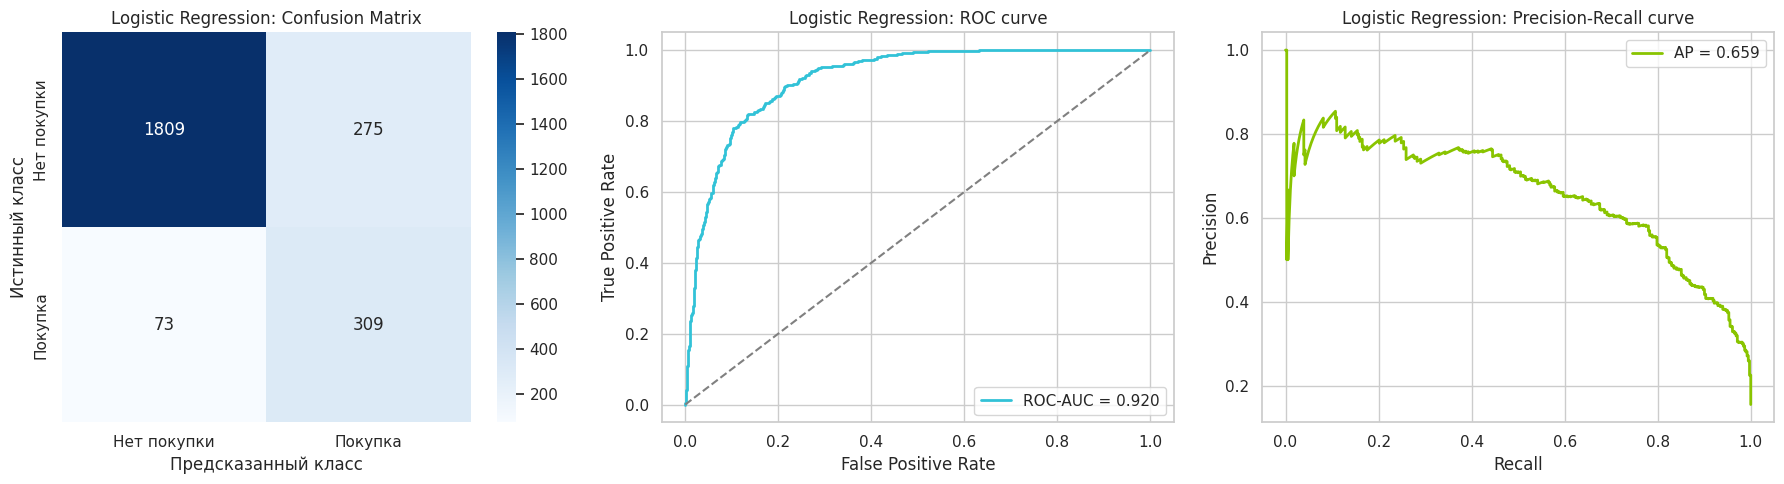

In [19]:
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_curve

logreg_pipeline = trained_models["Logistic Regression"]
logreg_pred = logreg_pipeline.predict(X_test)
logreg_proba = logreg_pipeline.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

logreg_cm = confusion_matrix(y_test, logreg_pred)
sns.heatmap(
    logreg_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Нет покупки", "Покупка"],
    yticklabels=["Нет покупки", "Покупка"],
    ax=axes[0],
)
axes[0].set_title("Logistic Regression: Confusion Matrix")
axes[0].set_xlabel("Предсказанный класс")
axes[0].set_ylabel("Истинный класс")

fpr, tpr, _ = roc_curve(y_test, logreg_proba)
logreg_auc = roc_auc_score(y_test, logreg_proba)
axes[1].plot(fpr, tpr, label=f"ROC-AUC = {logreg_auc:.3f}", color="#32C2D7", linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("Logistic Regression: ROC curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

precision_curve, recall_curve, _ = precision_recall_curve(y_test, logreg_proba)
avg_precision = average_precision_score(y_test, logreg_proba)
axes[2].plot(recall_curve, precision_curve, label=f"AP = {avg_precision:.3f}", color="#89C400", linewidth=2)
axes[2].set_title("Logistic Regression: Precision-Recall curve")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend()

plt.tight_layout()
plt.show()


,feature,coefficient,abs_coefficient
47,numeric_categorical__Browser_12,2.111343,2.111343
34,numeric_categorical__OperatingSystems_7,1.555188,1.555188
42,numeric_categorical__Browser_7,-1.484408,1.484408
73,numeric_categorical__TrafficType_16,1.404458,1.404458
14,numeric__HasPageValue,1.358035,1.358035
72,numeric_categorical__TrafficType_15,-1.185750,1.185750
22,string_categorical__Month_Nov,1.148937,1.148937
17,string_categorical__Month_Feb,-1.121267,1.121267
33,numeric_categorical__OperatingSystems_6,-0.875340,0.875340
21,string_categorical__Month_May,-0.778813,0.778813


/tmp/ipykernel_553/1834558284.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


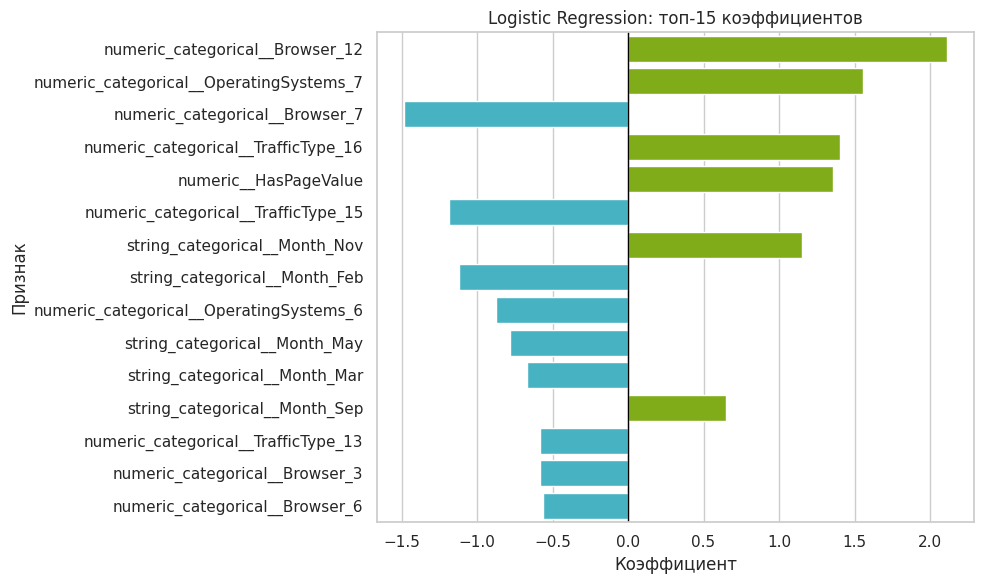

In [26]:
logreg_preprocessor = logreg_pipeline.named_steps["preprocessor"]
logreg_model = logreg_pipeline.named_steps["model"]

try:
    logreg_feature_names = logreg_preprocessor.get_feature_names_out()
except Exception:
    logreg_feature_names = np.array(
        [f"feature_{i}" for i in range(logreg_preprocessor.transform(X_train.iloc[:1]).shape[1])]
    )

coef_df = pd.DataFrame(
    {
        "feature": logreg_feature_names,
        "coefficient": logreg_model.coef_[0],
    }
)
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
top_coef_df = coef_df.sort_values("abs_coefficient", ascending=False).head(15)

display(top_coef_df)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_coef_df,
    y="feature",
    x="coefficient",
    palette=["#89C400" if value > 0 else "#32C2D7" for value in top_coef_df["coefficient"]],
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Logistic Regression: топ-15 коэффициентов")
plt.xlabel("Коэффициент")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()


- Интерпретация: положительные коэффициенты повышают вероятность покупки.
- Отрицательные — снижают.

 Значение важно сравнивать после preprocessing, так как числовые признаки масштабируются, а категориальные кодируются через OneHotEncoder.

# 15. Кросс-валидация лучшей модели

Дополнительно проверяю лучшую модель через StratifiedKFold. Это снижает зависимость оценки от одного разбиения train/test и усиливает раздел про корректность валидации.

Здесь считаю среднее и стандартное отклонение по нескольким метрикам: accuracy, precision, recall, F1-score и ROC-AUC.


In [27]:
best_model_name = str(comparison.iloc[0]["model"])
best_model = trained_models[best_model_name]
best_metrics = metrics_by_model[best_model_name]

cv_5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

cv_results = cross_validate(
    best_model,
    X,
    y,
    cv=cv_5,
    scoring=cv_scoring,
    n_jobs=-1,
    return_train_score=False,
)

cv_summary = pd.DataFrame(
    [
        {
            "metric": metric,
            "mean": cv_results[f"test_{metric}"].mean(),
            "std": cv_results[f"test_{metric}"].std(),
        }
        for metric in cv_scoring
    ]
)

display(cv_summary)
print(f"Лучшая модель для cross-validation: {best_model_name}")

,metric,mean,std
0,accuracy,0.900892,0.005210
1,precision,0.673930,0.019183
2,recall,0.698095,0.024777
3,f1,0.685465,0.016245
4,roc_auc,0.929683,0.004309


Лучшая модель для cross-validation: Random Forest Tuned


## Вывод по кросс-валидации

По результатам кросс-валидации модель `Random Forest Tuned` показывает стабильное качество на разных разбиениях данных. Средний `F1-score` равен примерно `0.685`, а средний `ROC-AUC` — примерно `0.930`.

Стандартное отклонение по метрикам небольшое: особенно по `accuracy` и `ROC-AUC`. Это говорит о том, что качество модели не зависит сильно от конкретного train/test-разбиения.

Также результаты кросс-валидации близки к test-метрикам финальной модели: на тестовой выборке `F1-score` был около `0.662`, а `ROC-AUC` около `0.923`. Значит, модель не выглядит переобученной и достаточно хорошо обобщает закономерности на новые данные.

# 16. Выбор лучшей модели

После сравнения всех моделей выбираю лучшую по значению F1-score, так как для этой задачи важно не только общее количество правильных ответов, но и баланс между precision и recall.

Из таблицы comparison беру модель с наилучшим результатом и сохраняю её отдельно вместе со всеми метриками.

Дальше формирую словарь metadata, где сохраняется основная информация о финальной модели:
- название лучшей модели,
- по какой метрике она выбиралась,
- значения основных метрик качества,
- список используемых признаков,
- название целевой переменной.


In [22]:
best_model_name = str(comparison.iloc[0]["model"])
best_model = trained_models[best_model_name]
best_metrics = metrics_by_model[best_model_name]

metadata = {
    "best_model_name": best_model_name,
    "selection_metric": "f1",
    "metrics": {
        "accuracy": float(best_metrics["accuracy"]),
        "precision": float(best_metrics["precision"]),
        "recall": float(best_metrics["recall"]),
        "f1": float(best_metrics["f1"]),
        "roc_auc": float(best_metrics["roc_auc"]),
    },
    "features": {
        "numeric": NUMERIC_FEATURES,
        "categorical": CATEGORICAL_FEATURES,
        "engineered": ENGINEERED_NUMERIC_FEATURES,
    },
    "target": TARGET_COLUMN,
}

print(f"Лучшая модель: {best_model_name}")
print(json.dumps(metadata, ensure_ascii=False, indent=2))

sample_input = X_test.iloc[[0]].copy()
sample_probability = float(best_model.predict_proba(sample_input)[0][1])
sample_prediction = bool(best_model.predict(sample_input)[0])

print("Пример single prediction:")
print({
    "prediction": sample_prediction,
    "prediction_label": "Покупка вероятна" if sample_prediction else "Покупка маловероятна",
    "purchase_probability": round(sample_probability, 4),
})


Лучшая модель: Random Forest Tuned
{
  "best_model_name": "Random Forest Tuned",
  "selection_metric": "f1",
  "metrics": {
    "accuracy": 0.8978102189781022,
    "precision": 0.6675257731958762,
    "recall": 0.6780104712041884,
    "f1": 0.6727272727272727,
    "roc_auc": 0.9252896664690334
  },
  "features": {
    "numeric": [
      "Administrative",
      "Administrative_Duration",
      "Informational",
      "Informational_Duration",
      "ProductRelated",
      "ProductRelated_Duration",
      "BounceRates",
      "ExitRates",
      "PageValues",
      "SpecialDay",
      "TotalPages",
      "TotalDuration",
      "ProductPagesShare",
      "AvgProductDuration",
      "HasPageValue"
    ],
    "categorical": [
      "Month",
      "VisitorType",
      "OperatingSystems",
      "Browser",
      "Region",
      "TrafficType",
      "Weekend"
    ],
    "engineered": [
      "TotalPages",
      "TotalDuration",
      "ProductPagesShare",
      "AvgProductDuration",
      "HasPage

# 17. Train/test comparison и анализ переобучения

Сравниваю качество лучшей модели на train и test. Если train-метрики намного выше test-метрик, это признак возможного переобучения.


In [23]:
train_metrics = evaluate_model(best_model, X_train, y_train)
test_metrics = evaluate_model(best_model, X_test, y_test)

train_test_comparison = pd.DataFrame(
    [
        {"sample": "train", **{k: train_metrics[k] for k in ["accuracy", "precision", "recall", "f1", "roc_auc"]}},
        {"sample": "test", **{k: test_metrics[k] for k in ["accuracy", "precision", "recall", "f1", "roc_auc"]}},
    ]
)

display(train_test_comparison)

f1_gap = train_metrics["f1"] - test_metrics["f1"]
print(f"Разница train F1 - test F1: {f1_gap:.4f}")
if f1_gap > 0.10:
    print("Есть признаки переобучения: качество на train заметно выше, чем на test.")
else:
    print("Сильного переобучения по F1 не видно: train и test достаточно близки.")


,sample,accuracy,precision,recall,f1,roc_auc
0,train,0.982766,0.907942,0.98886,0.946675,0.998547
1,test,0.897810,0.667526,0.67801,0.672727,0.925290


Разница train F1 - test F1: 0.2739
Есть признаки переобучения: качество на train заметно выше, чем на test.


### Вывод по переобучению

Сравнение train и test метрик показывает признаки переобучения: на обучающей выборке модель получает заметно более высокое качество, чем на тестовой. Например, `F1-score` на train равен примерно `0.947`, а на test — около `0.673`.

Это означает, что Random Forest частично подстроился под обучающие данные. Для ансамбля деревьев это ожидаемый риск, особенно если деревья достаточно глубокие.

При этом модель нельзя считать нерабочей: качество на test остаётся приемлемым, а результаты cross-validation близки к test-метрикам (`F1 ≈ 0.685`, `ROC-AUC ≈ 0.930`). Поэтому финальная модель имеет признаки переобучения, но сохраняет хорошую обобщающую способность на новых данных.

Для дальнейшего уменьшения переобучения можно сильнее ограничить сложность деревьев: уменьшить `max_depth`, увеличить `min_samples_leaf` или расширить поиск гиперпараметров.

# 18. Интерпретация: важность признаков

Для лучшей модели вывожу важность признаков. Это помогает объяснить, какие факторы сильнее всего влияют на прогноз покупки.

Сначала показываю важность после всех преобразований pipeline, а затем агрегирую OneHot-признаки обратно до исходных колонок, чтобы вывод был понятнее для защиты проекта.


,feature,importance
8,numeric__PageValues,0.217638
14,numeric__HasPageValue,0.209732
7,numeric__ExitRates,0.057738
11,numeric__TotalDuration,0.050623
5,numeric__ProductRelated_Duration,0.047031
6,numeric__BounceRates,0.037725
13,numeric__AvgProductDuration,0.037367
4,numeric__ProductRelated,0.036431
12,numeric__ProductPagesShare,0.036156
10,numeric__TotalPages,0.035204


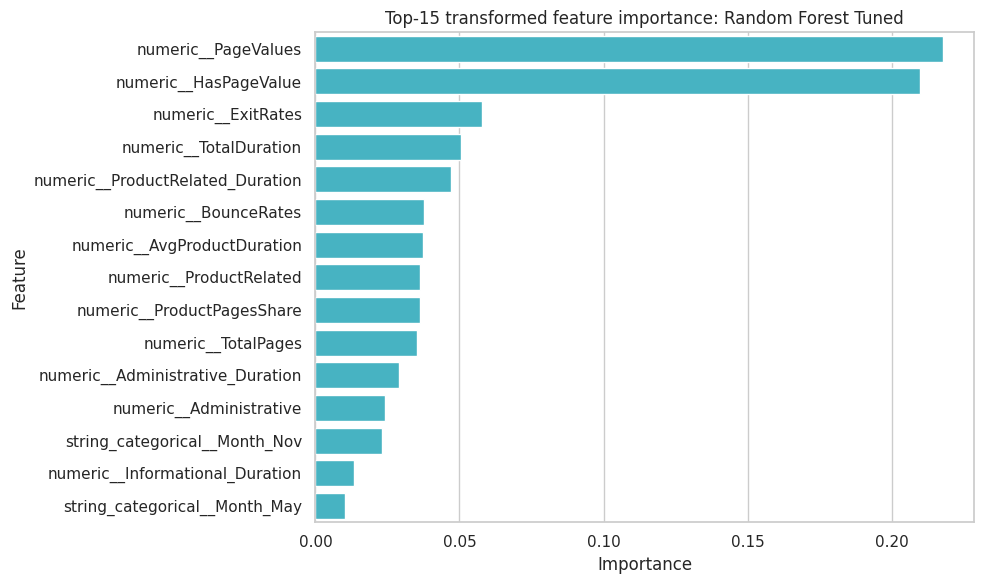

,base_feature,importance
8,PageValues,0.217638
5,HasPageValue,0.209732
4,ExitRates,0.057738
13,TotalDuration,0.050623
11,ProductRelated_Duration,0.047031
3,BounceRates,0.037725
2,AvgProductDuration,0.037367
10,ProductRelated,0.036431
9,ProductPagesShare,0.036156
14,TotalPages,0.035204


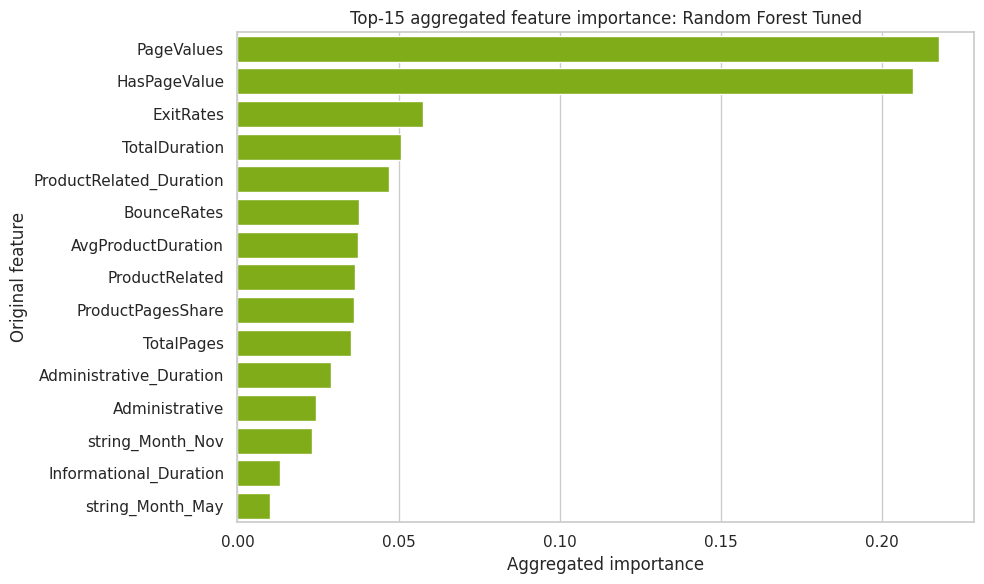

In [28]:
def get_transformed_feature_names(pipeline: Pipeline) -> np.ndarray:
    preprocessor = pipeline.named_steps["preprocessor"]
    try:
        return preprocessor.get_feature_names_out()
    except Exception:
        return np.array([f"feature_{i}" for i in range(preprocessor.transform(X_train.iloc[:1]).shape[1])])


def get_model_importances(pipeline: Pipeline) -> np.ndarray:
    model = pipeline.named_steps["model"]
    if hasattr(model, "get_feature_importance"):
        return np.asarray(model.get_feature_importance())
    if hasattr(model, "feature_importances_"):
        return np.asarray(model.feature_importances_)
    if hasattr(model, "coef_"):
        return np.abs(model.coef_[0])
    raise AttributeError("Для этой модели нет встроенной важности признаков.")


def get_base_feature_name(transformed_name: str) -> str:
    name = transformed_name.replace("numeric__", "").replace("categorical__", "")
    for feature in CATEGORICAL_FEATURES:
        if name == feature or name.startswith(f"{feature}_"):
            return feature
    return name


try:
    feature_names = get_transformed_feature_names(best_model)
    importances = get_model_importances(best_model)
    importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
    importance_df = importance_df.sort_values("importance", ascending=False)
    top_importance_df = importance_df.head(15)

    display(top_importance_df)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_importance_df, y="feature", x="importance", color="#32C2D7")
    plt.title(f"Top-15 transformed feature importance: {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    importance_df["base_feature"] = importance_df["feature"].apply(get_base_feature_name)
    grouped_importance_df = (
        importance_df.groupby("base_feature", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
        .head(15)
    )

    display(grouped_importance_df)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=grouped_importance_df, y="base_feature", x="importance", color="#89C400")
    plt.title(f"Top-15 aggregated feature importance: {best_model_name}")
    plt.xlabel("Aggregated importance")
    plt.ylabel("Original feature")
    plt.tight_layout()
    plt.show()
except Exception as error:
    print(f"Не удалось получить важность признаков: {error}")


## Вывод по важности признаков

Анализ важности признаков показывает, что финальная модель `Random Forest Tuned` в первую очередь опирается на поведенческие признаки пользователя.

Самыми важными признаками стали `PageValues` и `HasPageValue`. Это логично для интернет-магазина: если страницы, которые посещал пользователь, имеют ненулевую или высокую ценность, вероятность покупки заметно возрастает. То есть модель хорошо улавливает связь между ценностью просмотренных страниц и фактом покупки.

Также среди важных признаков находятся `ExitRates`, `BounceRates`, `ProductRelated`, `ProductRelated_Duration`, `TotalPages` и `TotalDuration`. Эти признаки описывают глубину и качество взаимодействия пользователя с сайтом: сколько страниц он просмотрел, сколько времени провёл на товарных страницах и насколько быстро покидал сайт.

Отдельно видно, что созданные признаки feature engineering тоже оказались полезными: `TotalDuration`, `TotalPages`, `ProductPagesShare`, `AvgProductDuration` и `HasPageValue` входят в число значимых признаков. Это подтверждает, что добавленные признаки не были формальными, а действительно помогают модели лучше описывать покупательское намерение.

Категориальные признаки, например `Month`, `TrafficType`, `Region`, `VisitorType`, тоже вносят вклад, но их влияние ниже, чем у поведенческих признаков. Это означает, что для прогноза покупки важнее не столько технические характеристики пользователя, сколько его действия внутри сессии.

Таким образом, модель выглядит интерпретируемой с точки зрения бизнеса: она принимает решение на основе логичных факторов — ценности страниц, глубины просмотра, длительности взаимодействия и показателей выхода/отказа.

# 19. Error analysis: разбор ошибок

Смотрю корректные и ошибочные предсказания лучшей модели. Это помогает понять, где модель ошибается:
- False Positive — модель ожидала покупку, но её не было;
- False Negative — пользователь реально купил, но модель этого не предсказала.

Для бизнеса особенно важны False Negative, потому что это потенциальные покупатели, которых система могла не выделить для маркетингового действия.


,count
case_type,
True Positive,259
True Negative,1955
False Positive,129
False Negative,123


/tmp/ipykernel_553/4114769209.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=case_counts.index, y=case_counts.values, palette=["#89C400", "#32C2D7", "#F2A541", "#D95D5D"])


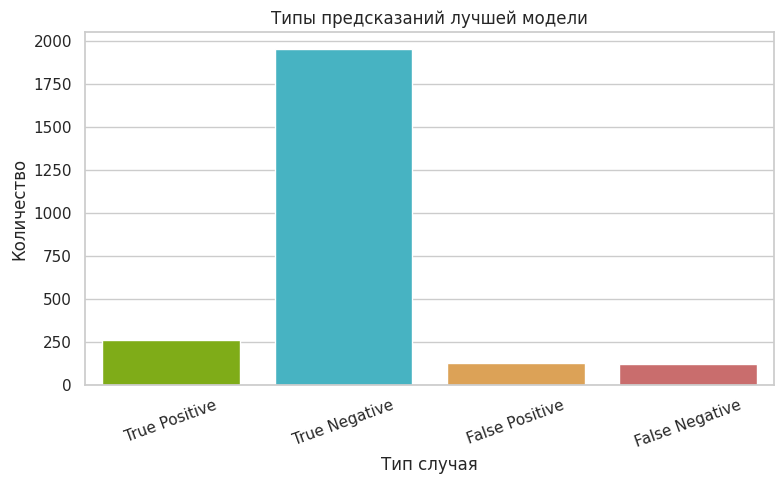

,count,mean_probability,mean_page_values,mean_exit_rates,mean_bounce_rates,mean_product_pages,mean_product_duration
case_type,,,,,,,
True Positive,259,0.747764,35.197306,0.017836,0.003776,47.366795,1905.622450
True Negative,1955,0.083027,0.604006,0.047441,0.025313,27.925320,1017.347423
False Positive,129,0.652542,24.559350,0.021611,0.006099,51.341085,2040.062644
False Negative,123,0.253513,4.165060,0.030011,0.011848,61.089431,2288.557268


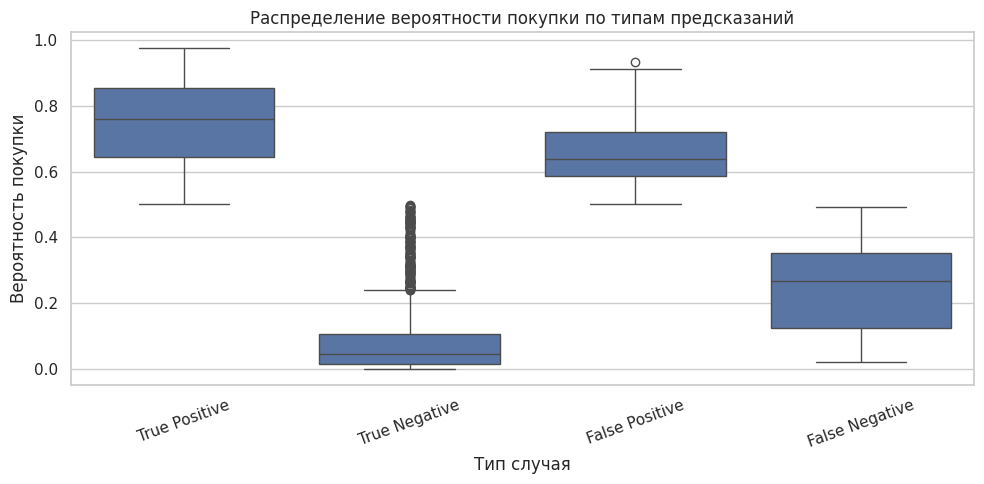


=== True Positive ===


,case_type,y_true,y_pred,purchase_probability,PageValues,ExitRates,BounceRates,ProductRelated,ProductRelated_Duration,VisitorType,Month
4659,True Positive,1,1,0.975978,23.988000,0.008333,0.0,13,893.216667,New_Visitor,May
4339,True Positive,1,1,0.969325,68.376000,0.002941,0.0,19,722.700000,New_Visitor,May
12234,True Positive,1,1,0.958277,81.027296,0.007059,0.0,36,872.833333,New_Visitor,Nov
4790,True Positive,1,1,0.957489,36.256000,0.022222,0.0,10,428.666667,New_Visitor,May
11720,True Positive,1,1,0.951019,14.132688,0.010526,0.0,21,455.083333,New_Visitor,Dec



=== True Negative ===


,case_type,y_true,y_pred,purchase_probability,PageValues,ExitRates,BounceRates,ProductRelated,ProductRelated_Duration,VisitorType,Month
1804,True Negative,0,0,0.0,0.0,0.2,0.2,1,0.0,Returning_Visitor,Mar
4494,True Negative,0,0,0.0,0.0,0.1,0.0,1,14.0,Returning_Visitor,May
5155,True Negative,0,0,0.0,0.0,0.2,0.2,2,0.0,Returning_Visitor,May
5198,True Negative,0,0,0.0,0.0,0.2,0.2,1,0.0,Returning_Visitor,May
5407,True Negative,0,0,0.0,0.0,0.2,0.2,1,0.0,Returning_Visitor,May



=== False Positive ===


,case_type,y_true,y_pred,purchase_probability,PageValues,ExitRates,BounceRates,ProductRelated,ProductRelated_Duration,VisitorType,Month
6429,False Positive,0,1,0.933097,166.373553,0.006250,0.000000,15,443.566667,New_Visitor,June
8553,False Positive,0,1,0.913800,12.585905,0.023077,0.000000,12,584.333333,Returning_Visitor,Nov
6054,False Positive,0,1,0.864463,63.553377,0.033333,0.000000,6,222.400000,Returning_Visitor,Jul
3286,False Positive,0,1,0.859509,26.875200,0.016667,0.000000,20,1187.500000,Returning_Visitor,May
4617,False Positive,0,1,0.834370,26.985000,0.030556,0.005556,17,344.333333,Returning_Visitor,May



=== False Negative ===


,case_type,y_true,y_pred,purchase_probability,PageValues,ExitRates,BounceRates,ProductRelated,ProductRelated_Duration,VisitorType,Month
11478,False Negative,1,0,0.022094,0.0,0.014286,0.000000,6,326.000000,New_Visitor,Dec
12086,False Negative,1,0,0.022640,0.0,0.066667,0.033333,6,60.250000,Returning_Visitor,Nov
6767,False Negative,1,0,0.025348,0.0,0.020000,0.010000,18,721.800000,Returning_Visitor,Oct
9042,False Negative,1,0,0.040922,0.0,0.046667,0.013333,12,276.250000,Returning_Visitor,Dec
6561,False Negative,1,0,0.043483,0.0,0.006944,0.008333,24,1433.163333,Returning_Visitor,Aug


In [29]:
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

error_df = X_test.copy()
error_df["y_true"] = y_test.values
error_df["y_pred"] = y_test_pred
error_df["purchase_probability"] = y_test_proba

conditions = [
    (error_df["y_true"] == 1) & (error_df["y_pred"] == 1),
    (error_df["y_true"] == 0) & (error_df["y_pred"] == 0),
    (error_df["y_true"] == 0) & (error_df["y_pred"] == 1),
    (error_df["y_true"] == 1) & (error_df["y_pred"] == 0),
]
choices = ["True Positive", "True Negative", "False Positive", "False Negative"]
error_df["case_type"] = np.select(conditions, choices, default="Other")

case_counts = error_df["case_type"].value_counts().reindex(choices)
display(case_counts.to_frame("count"))

plt.figure(figsize=(8, 5))
sns.barplot(x=case_counts.index, y=case_counts.values, palette=["#89C400", "#32C2D7", "#F2A541", "#D95D5D"])
plt.title("Типы предсказаний лучшей модели")
plt.xlabel("Тип случая")
plt.ylabel("Количество")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

error_summary = (
    error_df.groupby("case_type")
    .agg(
        count=("case_type", "size"),
        mean_probability=("purchase_probability", "mean"),
        mean_page_values=("PageValues", "mean"),
        mean_exit_rates=("ExitRates", "mean"),
        mean_bounce_rates=("BounceRates", "mean"),
        mean_product_pages=("ProductRelated", "mean"),
        mean_product_duration=("ProductRelated_Duration", "mean"),
    )
    .reindex(choices)
)
display(error_summary)

plt.figure(figsize=(10, 5))
sns.boxplot(data=error_df, x="case_type", y="purchase_probability", order=choices)
plt.title("Распределение вероятности покупки по типам предсказаний")
plt.xlabel("Тип случая")
plt.ylabel("Вероятность покупки")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

important_columns = [
    "case_type",
    "y_true",
    "y_pred",
    "purchase_probability",
    "PageValues",
    "ExitRates",
    "BounceRates",
    "ProductRelated",
    "ProductRelated_Duration",
    "VisitorType",
    "Month",
]

for case_type in choices:
    print(f"\n=== {case_type} ===")
    case_part = error_df[error_df["case_type"] == case_type]
    ascending = case_type in ["False Negative", "True Negative"]
    display(
        case_part.sort_values("purchase_probability", ascending=ascending)
        .head(5)[important_columns]
    )


## Вывод по ошибкам
Вывод:
- false negative важны для бизнеса, потому что это реальные покупки, которые модель не нашла.
- False positive менее критичны, но могут приводить к лишним маркетинговым действиям.

Такой анализ помогает выбрать порог вероятности и понять, какие сессии модель путает чаще всего.


# Итоговый вывод

В рамках проекта была построена ML-система для предсказания покупательского намерения в интернет-магазине. В ноутбуке выполнены загрузка данных, EDA, анализ дисбаланса классов, feature engineering, preprocessing, обучение нескольких моделей, подбор гиперпараметров и сравнение качества.

Лучшей моделью по основной метрике F1-score стала Random Forest Tuned. Она показала наиболее удачный баланс между поиском реальных покупателей и количеством ложных срабатываний. При этом ROC-AUC остаётся высоким, что говорит о хорошей способности модели разделять сессии с покупкой и без покупки.

Практическая ценность решения заключается в том, что интернет-магазин может использовать вероятность покупки для приоритизации маркетинговых действий: например, показывать персональные предложения пользователям с высокой вероятностью покупки или дополнительно анализировать сессии, где модель не уверена.

Ограничения проекта: модель обучена на исторических данных, поведение пользователей может меняться со временем, а вероятность покупки не является гарантией покупки. Поэтому при реальном внедрении модель нужно периодически переобучать и контролировать качество на новых данных.
